In [1]:
import pandas as pd  
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

In this notebook we will review the data scraped in the `data_scraping.ipynb` notebook and perform wrangling to produce dataset that can be readily used in other notebooks.

## Data Review

In [2]:
# loading data

raw_data = pd.read_csv('../data/uefa_results.csv')
raw_data.head()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
0,1978/79,CL,Qualifying Round,AS Monaco,Fra,Steaua Bucuresti,Rom,3-0,0-2,3-2,no,no
1,1978/79,CL,Round 1,Nottingham Forest,Eng,Liverpool,Eng,2-0,0-0,2-0,no,no
2,1978/79,CL,Round 1,Juventus,Ita,Glasgow Rangers,Sco,1-0,0-2,1-2,no,no
3,1978/79,CL,Round 1,Linfield Belfast,Nir,Lillestrøm SK,Nor,0-0,0-1,0-1,no,no
4,1978/79,CL,Round 1,Real Madrid,Esp,Progrès Niederkorn,Lux,5-0,7-0,12-0,no,no


In [3]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12748 entries, 0 to 12747
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   season           12748 non-null  str  
 1   competition      12748 non-null  str  
 2   round            12748 non-null  str  
 3   team_a           12748 non-null  str  
 4   country_a        12748 non-null  str  
 5   team_b           12748 non-null  str  
 6   country_b        12748 non-null  str  
 7   score_leg1       12748 non-null  str  
 8   score_leg2       11196 non-null  str  
 9   score_aggregate  12748 non-null  str  
 10  extra_time       12748 non-null  str  
 11  penalties        12748 non-null  str  
dtypes: str(12)
memory usage: 1.2 MB


In [4]:
raw_data.nunique()

season               48
competition           4
round                20
team_a             1015
country_a            59
team_b              961
country_b            59
score_leg1           63
score_leg2           68
score_aggregate     135
extra_time            1
penalties             1
dtype: int64

In [5]:
np.sort(raw_data['country_a'].unique())

array(['Alb', 'And', 'Arm', 'Aut', 'Azb', 'Bel', 'Bls', 'Bos', 'Bul',
       'Cro', 'Cyp', 'Cze', 'Den', 'Eng', 'Esp', 'Est', 'Far', 'Fin',
       'Fra', 'GDR', 'Geo', 'Ger', 'Gib', 'Gre', 'Hun', 'Irl', 'Isl',
       'Isr', 'Ita', 'Kaz', 'Kos', 'Lat', 'Lie', 'Lit', 'Lux', 'Mac',
       'Mlt', 'Mol', 'Mon', 'Ned', 'Nir', 'Nor', 'Pol', 'Por', 'Rom',
       'Rus', 'Sco', 'Slo', 'Sma', 'Srb', 'Sui', 'Svk', 'Swe', 'TCH',
       'Tur', 'URS', 'Ukr', 'Wal', 'YUG'], dtype=object)

In [6]:
raw_data['score_leg1'].head()

0    3-0
1    2-0
2    1-0
3    0-0
4    5-0
Name: score_leg1, dtype: str

In [14]:
raw_data[raw_data['team_a'] == 'Napoli']

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
191,1979/80,EL,Round 1,Napoli,Ita,Olympiakos Piraeus,Gre,2-0,0-1,2-1,no,no
460,1981/82,EL,Round 1,Napoli,Ita,Radnicki Nis,YUG,2-2,0-0,2-2,no,no
614,1982/83,EL,Round 2,Napoli,Ita,1.FC Kaiserslautern,Ger,1-2,0-2,1-4,no,no
1097,1986/87,EL,Round 1,Napoli,Ita,Toulouse FC,Fra,1-0,0-1,1-1,no,no
1345,1988/89,EL,Round 1,Napoli,Ita,PAOK Thessaloniki,Gre,1-0,1-1,2-1,no,no
1378,1988/89,EL,Semi Finals,Napoli,Ita,Bayern München,Ger,2-0,2-2,4-2,no,no
1380,1988/89,EL,Final,Napoli,Ita,VfB Stuttgart,Ger,2-1,3-3,5-4,no,no
1497,1989/90,EL,Round 3,Napoli,Ita,Werder Bremen,Ger,2-3,1-5,3-8,no,no
1513,1990/91,CL,Round 1,Napoli,Ita,Újpest Dózsa,Hun,3-0,2-0,5-0,no,no
1525,1990/91,CL,Round 2,Napoli,Ita,Spartak Moscow,URS,0-0,0-0,0-0,no,no


In [26]:
def country_season_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-country season stats for every team from that country.

    Each match leg (`score_leg1`, `score_leg2`) is treated as a separate game.
    Each team contributes stats for its country (so foreign opponents are included).

    Returns a DataFrame with columns:
      - country
      - season
      - wins
      - draws
      - losses
      - goals_for
      - goals_against

    Args:
        df: Raw data frame with columns ['season', 'team_a', 'team_b', 'country_a', 'country_b', 'score_leg1', 'score_leg2'].
    """

    def _parse_score(score: str):
        if pd.isna(score):
            return None, None
        parts = str(score).split("-")
        if len(parts) != 2:
            return None, None
        try:
            return int(parts[0].strip()), int(parts[1].strip())
        except ValueError:
            return None, None

    def _expand_leg(df_leg: pd.DataFrame, score_col: str, team_col: str, opp_col: str, country_col: str, reverse_score: bool = False):
        tmp = df_leg[["season", team_col, opp_col, country_col, score_col]].copy()
        tmp = tmp.rename(columns={
            team_col: "team",
            opp_col: "opp",
            country_col: "country",
            score_col: "score",
        })

        parsed = tmp["score"].apply(_parse_score).tolist()
        if reverse_score:
            # For away team: goals_for is the second number, goals_against is the first
            tmp[["goals_against", "goals_for"]] = pd.DataFrame(parsed, index=tmp.index)
        else:
            # For home team: goals_for is the first number, goals_against is the second
            tmp[["goals_for", "goals_against"]] = pd.DataFrame(parsed, index=tmp.index)

        # Determine result from the perspective of `team`
        tmp["result"] = np.where(
            tmp["goals_for"] > tmp["goals_against"],
            "W",
            np.where(tmp["goals_for"] < tmp["goals_against"], "L", "D"),
        )

        return tmp.drop(columns=["score", "opp"])

    # Expand all 4 combinations: both teams in both legs
    # Leg 1: score_leg1 = team_a_goals - team_b_goals
    leg1_team_a = _expand_leg(df, "score_leg1", "team_a", "team_b", "country_a", reverse_score=False)
    leg1_team_b = _expand_leg(df, "score_leg1", "team_b", "team_a", "country_b", reverse_score=True)
    
    # Leg 2: score_leg2 = team_a_goals - team_b_goals (same format as leg1)
    leg2_team_a = _expand_leg(df, "score_leg2", "team_a", "team_b", "country_a", reverse_score=False)
    leg2_team_b = _expand_leg(df, "score_leg2", "team_b", "team_a", "country_b", reverse_score=True)

    matches = pd.concat([leg1_team_a, leg1_team_b, leg2_team_a, leg2_team_b], ignore_index=True, sort=False)

    matches = matches.dropna(subset=["goals_for", "goals_against"])

    stats = (
        matches.groupby(["country", "season"])
        .agg(
            wins=("result", lambda s: (s == "W").sum()),
            draws=("result", lambda s: (s == "D").sum()),
            losses=("result", lambda s: (s == "L").sum()),
            goals_for=("goals_for", "sum"),
            goals_against=("goals_against", "sum"),
        )
        .reset_index()
    )

    return stats


# Example usage:
country_stats = country_season_stats(raw_data)
country_stats.head()


,country,season,wins,draws,losses,goals_for,goals_against
0,Alb,1978/79,1,0,1,3.0,4.0
1,Alb,1979/80,1,0,1,2.0,4.0
2,Alb,1980/81,0,1,3,0.0,4.0
3,Alb,1981/82,2,0,2,3.0,7.0
4,Alb,1982/83,1,1,2,2.0,3.0


In [27]:
raw_data[(raw_data['season'] == '1978/79') & (raw_data['country_a'] == 'Ita')]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
2,1978/79,CL,Round 1,Juventus,Ita,Glasgow Rangers,Sco,1-0,0-2,1-2,no,no
51,1978/79,CW,Round 2,Internazionale,Ita,Bodø/Glimt,Nor,5-0,2-1,7-1,no,no
55,1978/79,CW,Quarter Finals,Internazionale,Ita,SK Beveren,Bel,0-0,0-1,0-1,no,no
63,1978/79,EL,Round 1,AC Milan,Ita,Lokomotiva Kosice,TCH,1-0,0-1,1-1,no,no
117,1978/79,EL,Round 3,AC Milan,Ita,Manchester City,Eng,2-2,0-3,2-5,no,no


In [28]:
raw_data[(raw_data['season'] == '1978/79') & (raw_data['country_b'] == 'Ita')]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
32,1978/79,CW,Round 1,Floriana,Mlt,Internazionale,Ita,1-3,0-5,1-8,no,no
62,1978/79,EL,Round 1,Dukla Praha,TCH,Vicenza,Ita,1-0,1-1,2-1,no,no
71,1978/79,EL,Round 1,Sporting Gijón,Esp,Torino,Ita,3-0,0-1,3-1,no,no
90,1978/79,EL,Round 1,Dinamo Tbilisi,URS,Napoli,Ita,2-0,1-1,3-1,no,no
109,1978/79,EL,Round 2,Levski-Spartak Sofia,Bul,AC Milan,Ita,1-1,0-3,1-4,no,no


In [30]:
country_stats[country_stats['country'] == 'Ita'][:3]

,country,season,wins,draws,losses,goals_for,goals_against
1091,Ita,1978/79,8,5,7,26.0,20.0
1092,Ita,1979/80,7,7,10,23.0,22.0
1093,Ita,1980/81,10,4,6,32.0,26.0


In [31]:
country_stats.shape

(2212, 7)

In [32]:
country_stats['p_win'] = country_stats['wins'] / (country_stats['wins'] + country_stats['draws'] + country_stats['losses'])
country_stats['goals_diff'] = country_stats['goals_for'] - country_stats['goals_against']

country_stats.head()

,country,season,wins,draws,losses,goals_for,goals_against,p_win,goals_diff
0,Alb,1978/79,1,0,1,3.0,4.0,0.50,-1.0
1,Alb,1979/80,1,0,1,2.0,4.0,0.50,-2.0
2,Alb,1980/81,0,1,3,0.0,4.0,0.00,-4.0
3,Alb,1981/82,2,0,2,3.0,7.0,0.50,-4.0
4,Alb,1982/83,1,1,2,2.0,3.0,0.25,-1.0


In [34]:
country_stats[country_stats['country'] == 'Ita'][:5]

,country,season,wins,draws,losses,goals_for,goals_against,p_win,goals_diff
1091,Ita,1978/79,8,5,7,26.0,20.0,0.400000,6.0
1092,Ita,1979/80,7,7,10,23.0,22.0,0.291667,1.0
1093,Ita,1980/81,10,4,6,32.0,26.0,0.500000,6.0
1094,Ita,1981/82,5,5,4,22.0,15.0,0.357143,7.0
1095,Ita,1982/83,12,5,12,40.0,33.0,0.413793,7.0


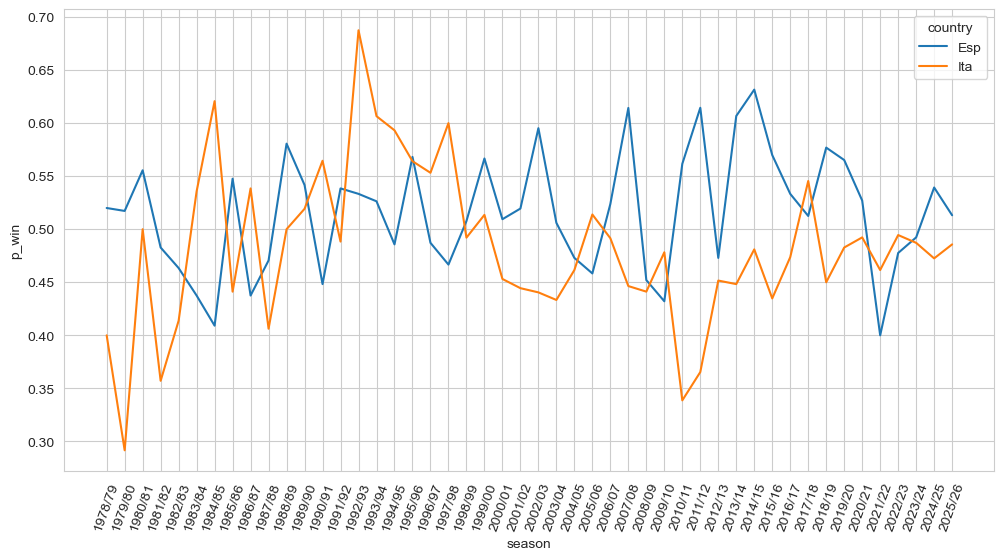

In [47]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

dataset = country_stats[(country_stats['country'] == 'Ita') |
                        (country_stats['country'] == 'Esp')].copy()

sns.lineplot(data=dataset, 
                x='season', 
                y='p_win',
                hue = 'country',)

plt.xticks(rotation=70);

In [48]:
country_stats[(country_stats['season'] == '2010/11') & (country_stats['country'] == 'Ita')]

,country,season,wins,draws,losses,goals_for,goals_against,p_win,goals_diff
1123,Ita,2010/11,21,19,22,82.0,91.0,0.33871,-9.0


In [51]:
raw_data[(raw_data['country_a'] == 'Ita') & (raw_data['season'] == '2010/11')].shape

(18, 12)

In [52]:
raw_data[(raw_data['country_b'] == 'Ita') & (raw_data['season'] == '2010/11')].shape

(13, 12)